# Comparison of empirical data and predicted data

In [1]:
from utils.metrics import smallest_angle, distance_PolarCoord, average_prediction
import numpy as np
import nibabel as nib
import os
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from python_visualization.visualization import roi

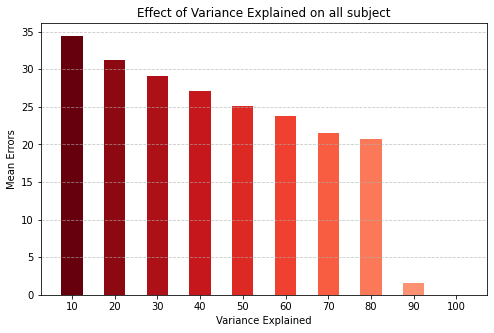

In [3]:
folder_path = '/neurodesktop-storage/nyu_retinotopy_data/freesurfer_test/'
# items = os.listdir(folder_path)
pattern = re.compile(r"^sub-wlsubj\d+$")
items = [
    item for item in os.listdir(folder_path)
    if os.path.isdir(os.path.join(folder_path, item)) and pattern.match(item)
]
# print(items)

# Setting thresholds
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
all_errors = []
for subject in items:
    empirical_path = folder_path + subject + '/surf/fs_empirical.lh.32k_fs_LR.func.gii'
    predicted_path = folder_path + subject + '/deepRetinotopy/' + subject + '.fs_predicted_polarAngle_lh_curvatureFeat_model.func.gii'
    vexpl_path = folder_path + subject + '/surf/fs_vexpl.lh.32k_fs_LR.func.gii'
    
    # Number of nodes
    number_cortical_nodes = int(64984)
    number_hemi_nodes = int(number_cortical_nodes / 2)
    
    # visual cortex mask
    final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi(['ROI'])
    
    empirical_data = np.array(nib.load(empirical_path).darrays[0].data).reshape(number_hemi_nodes, 1)
    predicted_data = np.array(nib.load(predicted_path).darrays[0].data).reshape(number_hemi_nodes, 1)
    vexpl_data = np.array(nib.load(vexpl_path).darrays[0].data)
    # vexpl_data = np.array(nib.load(vexpl_path).darrays[0].data).reshape(number_hemi_nodes, 1)
    
    # Applying Mask
    # empirical_data[final_mask_L == 1] = np.reshape(empirical_data[final_mask_L == 1], (-1, 1))
    # predicted_data[final_mask_L == 1] = np.reshape(predicted_data[final_mask_L == 1], (-1, 1))
    # vexpl_data[final_mask_L == 1] = np.reshape(vexpl_data[final_mask_L == 1], (-1, 1))
    empirical_data = empirical_data[final_mask_L == 1].reshape(-1, 1)
    predicted_data = predicted_data[final_mask_L == 1].reshape(-1, 1)
    vexpl_data = vexpl_data[final_mask_L == 1]
    # vexpl_data = vexpl_data[final_mask_L == 1].reshape(-1, 1)
    
    
    # Transforming angle to radians
    angle_error = smallest_angle(empirical_data*np.pi/180, predicted_data*np.pi/180)

    errors = []
    for thresh in thresholds:
        mask = vexpl_data > (thresh / 100)
        errors.append(np.mean(angle_error[mask]))
        # print(f"Threshold {thresh}% - Valid Data Points: {np.sum(mask)}")
        
    errors = np.nan_to_num(errors, nan=0)
    all_errors.append(errors)
    # print(subject, errors)

all_errors = np.array(all_errors)
mean_errors = np.nanmean(all_errors, axis=0)

# Plot
colors = cm.Reds(np.linspace(1, 0.3, len(mean_errors)))
plt.figure(figsize=(8, 5))
plt.bar(thresholds, mean_errors, width=5.0, color=colors, alpha=1.0)
plt.xticks(thresholds)
plt.xlabel("Variance Explained")
plt.ylabel("Mean Errors")
plt.title("Effect of Variance Explained on all subject")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()    

(array([ 43.,  90., 322., 746., 811., 714., 380., 101.,  37.,  23.]),
 array([ 27.23423576,  57.7673111 ,  88.30038452, 118.83345795,
        149.36653137, 179.89959717, 210.43267822, 240.96574402,
        271.49880981, 302.03189087, 332.56497192]),
 <BarContainer object of 10 artists>)

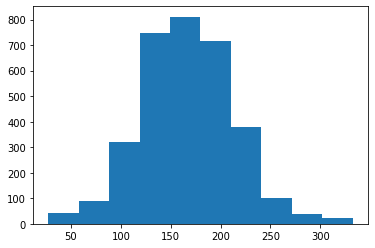

In [4]:
plt.hist(empirical_data)

(array([103., 231., 238., 292., 684., 699., 443., 361., 119.,  97.]),
 array([103.19172668, 118.21786499, 133.2440033 , 148.2701416 ,
        163.29627991, 178.32241821, 193.34855652, 208.37469482,
        223.40083313, 238.42697144, 253.45310974]),
 <BarContainer object of 10 artists>)

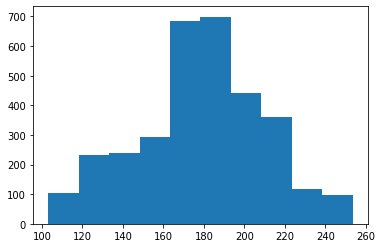

In [5]:
plt.hist(predicted_data)

(array([383., 185., 165., 173., 182., 229., 388., 542., 708., 312.]),
 array([0.00217566, 0.09110859, 0.18004152, 0.26897445, 0.35790738,
        0.44684032, 0.53577322, 0.62470615, 0.71363908, 0.80257201,
        0.89150494]),
 <BarContainer object of 10 artists>)

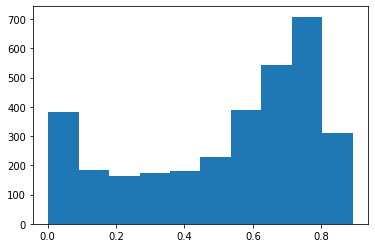

In [6]:
plt.hist(vexpl_data)

(array([1261.,  815.,  534.,  290.,  149.,   79.,   63.,   45.,   24.,
           7.]),
 array([5.30569069e-02, 1.74673252e+01, 3.48815918e+01, 5.22958603e+01,
        6.97101288e+01, 8.71243973e+01, 1.04538666e+02, 1.21952934e+02,
        1.39367203e+02, 1.56781479e+02, 1.74195740e+02]),
 <BarContainer object of 10 artists>)

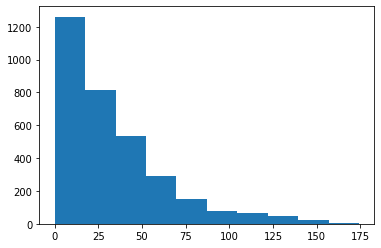

In [7]:
plt.hist(angle_error)

(array([2., 0., 0., 0., 0., 0., 0., 0., 4., 4.]),
 array([ 0.        ,  2.92428279,  5.84856558,  8.77284813, 11.69713116,
        14.62141418, 17.54569626, 20.46998024, 23.39426231, 26.3185463 ,
        29.24282837]),
 <BarContainer object of 10 artists>)

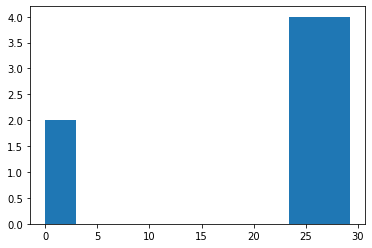

In [8]:
plt.hist(errors)

(array([[ 0.,  0.,  0.,  4., 16.,  7.,  4.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  9., 16.,  5.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 17., 10.,  3.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  2., 19.,  9.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  3., 21.,  6.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 11., 15.,  5.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1., 14., 13.,  3.,  0.,  0.,  0.,  0.,  0.],
        [ 2.,  4., 12.,  8.,  4.,  0.,  0.,  0.,  0.,  1.],
        [30.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
        [31.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([ 0.        ,  7.04336023, 14.08672047, 21.13008118, 28.17344093,
        35.21680069, 42.26016235, 49.3035202 , 56.34688187, 63.39023972,
        70.43360138]),
 <a list of 10 BarContainer objects>)

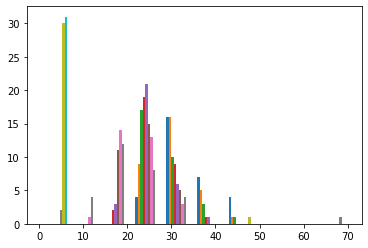

In [9]:
plt.hist(all_errors)

# Single subject

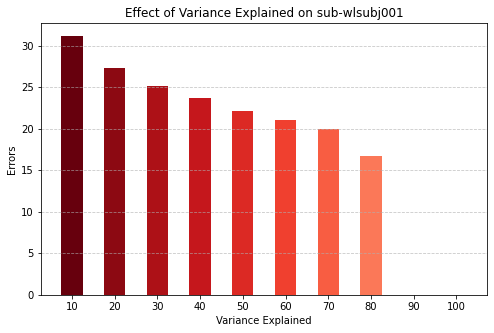

In [4]:
subject = 'sub-wlsubj001'
empirical_path = '/neurodesktop-storage/nyu_retinotopy_data/freesurfer_test/' + subject + '/surf/fs_empirical.lh.32k_fs_LR.func.gii'
predicted_path = '/neurodesktop-storage/nyu_retinotopy_data/freesurfer_test/' + subject + '/deepRetinotopy/' + subject + '.fs_predicted_polarAngle_lh_curvatureFeat_model.func.gii'
vexpl_path = '/neurodesktop-storage/nyu_retinotopy_data/freesurfer_test/' + subject + '/surf/fs_vexpl.lh.32k_fs_LR.func.gii'

# Number of nodes
number_cortical_nodes = int(64984)
number_hemi_nodes = int(number_cortical_nodes / 2)

# visual cortex mask
final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi(['ROI'])

empirical_data = np.array(nib.load(empirical_path).darrays[0].data).reshape(number_hemi_nodes, 1)
predicted_data = np.array(nib.load(predicted_path).darrays[0].data).reshape(number_hemi_nodes, 1)
vexpl_data = np.array(nib.load(vexpl_path).darrays[0].data)
# vexpl_data = np.array(nib.load(vexpl_path).darrays[0].data).reshape(number_hemi_nodes, 1)

# Applying Mask
# empirical_data[final_mask_L == 1] = np.reshape(empirical_data[final_mask_L == 1], (-1, 1))
# predicted_data[final_mask_L == 1] = np.reshape(predicted_data[final_mask_L == 1], (-1, 1))
# vexpl_data[final_mask_L == 1] = np.reshape(vexpl_data[final_mask_L == 1], (-1, 1))
empirical_data = empirical_data[final_mask_L == 1].reshape(-1, 1)
predicted_data = predicted_data[final_mask_L == 1].reshape(-1, 1)
vexpl_data = vexpl_data[final_mask_L == 1]
# vexpl_data = vexpl_data[final_mask_L == 1].reshape(-1, 1)


# Transforming angle to radians
angle_error = smallest_angle(empirical_data*np.pi/180, predicted_data*np.pi/180)

# Setting thresholds
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
errors = []

for thresh in thresholds:
    mask = vexpl_data > (thresh / 100)
    errors.append(np.mean(angle_error[mask]))
    # print(f"Threshold {thresh}% - Valid Data Points: {np.sum(mask)}")
    
errors = np.nan_to_num(errors, nan=0)
# print('errors: ', errors)
colors = cm.Reds(np.linspace(1, 0.3, len(errors)))
plt.figure(figsize=(8, 5))
plt.bar(thresholds, errors, width=5.0, color=colors, alpha=1.0)
plt.xticks(thresholds)
plt.xlabel("Variance Explained")
plt.ylabel("Errors")
plt.title("Effect of Variance Explained on sub-wlsubj001")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()